## E.PageRank

## Contoh Melakukan PageRank

In [ ]:
import numpy as np

def pagerank(adj_matrix, d=0.85, max_iter=100, tol=1e-6):
    """
    Hitung PageRank dari matriks adjacency.

    Parameters:
        adj_matrix : array-like, shape (n, n)
            Matriks adjacency (1 jika ada link i -> j)
        d : float
            Damping factor (default: 0.85)
        max_iter : int
            Maksimum iterasi
        tol : float
            Toleransi konvergensi

    Returns:
        r : ndarray, shape (n,)
            Vektor PageRank
    """
    adj = np.array(adj_matrix, dtype=float)
    n = adj.shape[0]

    # Tangani dangling nodes (baris dengan jumlah 0)
    out_degree = np.sum(adj, axis=1)
    for i in range(n):
        if out_degree[i] == 0:
            adj[i, :] = 1.0  # taut ke semua halaman

    # Normalisasi baris → jadi matriks transisi (baris jumlah = 1)
    # TAPI: PageRank asli menggunakan TRANSPOSE → aliran masuk
    # Jadi kita transpos untuk membuat kolom = out-link
    M = adj / np.sum(adj, axis=1, keepdims=True)
    M = M.T  # Sekarang M[j,i] = probabilitas dari i ke j

    # Inisialisasi
    r = np.ones(n) / n
    teleport = (1 - d) / n

    for _ in range(max_iter):
        r_new = d * M @ r + teleport
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new

    return r

# Contoh penggunaan
if __name__ == "__main__":
    # Graf: 0 → 1, 0 → 2, 1 → 2, 2 → 0
    A = [
        [0, 1, 1],  # 0 links to 1 and 2
        [0, 0, 1],  # 1 links to 2
        [1, 0, 0],  # 2 links to 0
    ]

    pr = pagerank(A)
    print("PageRank:")
    for i, score in enumerate(pr):
        print(f"Node {i}: {score:.4f}")

PageRank:
Node 0: 0.3878
Node 1: 0.2148
Node 2: 0.3974


In [ ]:
import networkx as nx

G = nx.DiGraph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (2, 0)])

pr = nx.pagerank(G, alpha=0.85)
print(pr)

{0: 0.387789442707259, 1: 0.21481051315058508, 2: 0.3974000441421556}


Nilai PageRank: {0: 0.387789442707259, 1: 0.21481051315058508, 2: 0.3974000441421556}


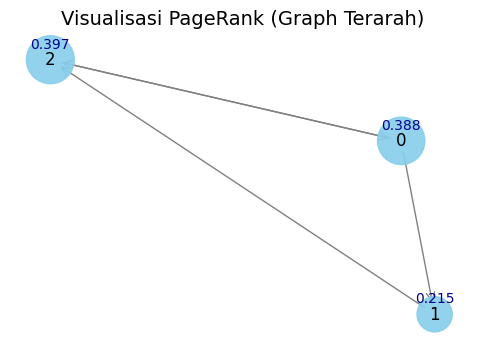

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Membuat graph terarah (directed graph)
G = nx.DiGraph()
G.add_edges_from([
    (0, 1),
    (0, 2),
    (1, 2),
    (2, 0)
])

# --- 2. Menghitung PageRank
pr = nx.pagerank(G, alpha=0.85)
print("Nilai PageRank:", pr)

# --- 3. Visualisasi Graph
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G, seed=42)  # posisi node biar rapi dan stabil

# Ukuran node berdasarkan nilai PageRank
node_size = [v * 3000 for v in pr.values()]

# Gambar node
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='skyblue', alpha=0.9)

# Gambar edge (panah antar node)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')

# Label node
nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')

# Label nilai PageRank di setiap node
for node, (x, y) in pos.items():
    plt.text(x, y + 0.08, f"{pr[node]:.3f}", ha='center', fontsize=10, color='darkblue')

plt.title("Visualisasi PageRank (Graph Terarah)", fontsize=14)
plt.axis("off")
plt.show()

=== Informasi Graf ===
Jumlah Node  : 10000
Jumlah Edge  : 78323

=== 5 Node dengan PageRank Tertinggi ===
1. Node 486980 -> PageRank: 0.006515
2. Node 285814 -> PageRank: 0.004633
3. Node 226374 -> PageRank: 0.003301
4. Node 163075 -> PageRank: 0.003288
5. Node 555924 -> PageRank: 0.002756

✅ Semua hasil PageRank telah disimpan ke 'hasil_pagerank_semua_node.csv'


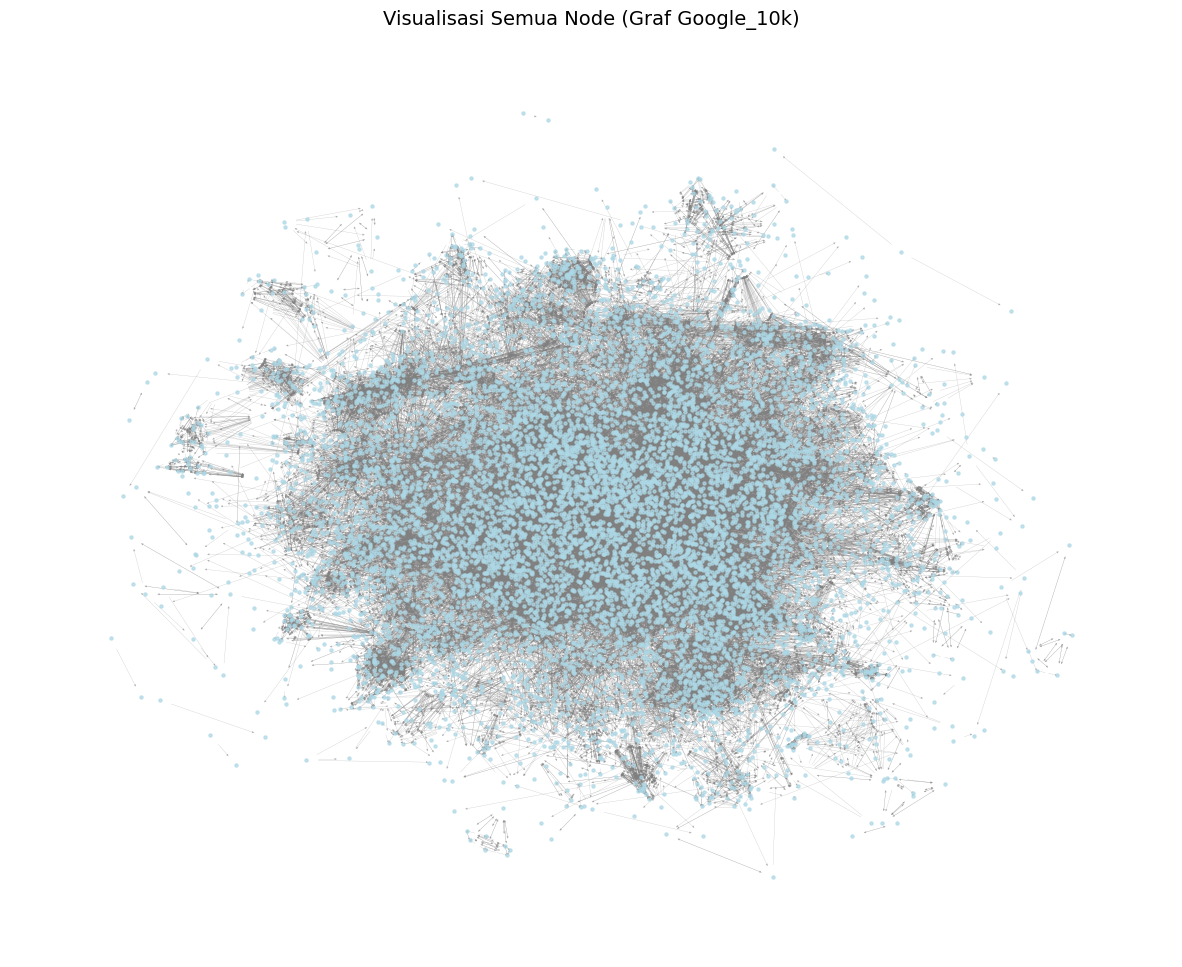

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Membaca dataset ---
file_path = "web-Google_10k.txt"
edges = pd.read_csv(file_path, sep="\t", comment="#", names=["FromNodeId", "ToNodeId"])

# --- 2. Membuat Graph Terarah ---
G = nx.DiGraph()
G.add_edges_from(edges.values)

print("=== Informasi Graf ===")
print(f"Jumlah Node  : {G.number_of_nodes()}")
print(f"Jumlah Edge  : {G.number_of_edges()}")

# --- 3. Menghitung PageRank ---
pagerank = nx.pagerank(G, alpha=0.85)

# --- 4. Menampilkan hanya 5 node dengan PageRank tertinggi ---
pagerank_df = pd.DataFrame(list(pagerank.items()), columns=["Node", "PageRank"]).sort_values(by="PageRank", ascending=False)

top5 = pagerank_df.head(5)
print("\n=== 5 Node dengan PageRank Tertinggi ===")
for i, (node, score) in enumerate(zip(top5['Node'], top5['PageRank']), start=1):
    print(f"{i}. Node {node} -> PageRank: {score:.6f}")

# Simpan seluruh hasil PageRank ke CSV (biar datanya tetap aman)
pagerank_df.to_csv("hasil_pagerank_semua_node.csv", index=False)
print("\n✅ Semua hasil PageRank telah disimpan ke 'hasil_pagerank_semua_node.csv'")

# --- 5. Visualisasi: semua node (agar lengkap) ---
plt.figure(figsize=(15, 12))

# Ganti layout agar tidak terlalu lama
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

nx.draw_networkx_nodes(G, pos,
                       node_size=5,
                       node_color='lightblue',
                       alpha=0.7)
nx.draw_networkx_edges(G, pos,
                       arrowsize=3,
                       width=0.2,
                       edge_color='gray',
                       alpha=0.5)

plt.title("Visualisasi Semua Node (Graf Google_10k)", fontsize=14)
plt.axis("off")
plt.show()

## Tugas Crawling link PageRank

Jumlah edge: 1708
Jumlah node: 131
Iterasi 1: selisih total = 0.66183206
Iterasi 2: selisih total = 0.07199924
Iterasi 3: selisih total = 0.03365008
Iterasi 4: selisih total = 0.01572694
Iterasi 5: selisih total = 0.00735025
Iterasi 6: selisih total = 0.00343527
Iterasi 7: selisih total = 0.00160553
Iterasi 8: selisih total = 0.00075037
Iterasi 9: selisih total = 0.00035070
Iterasi 10: selisih total = 0.00016391
Iterasi 11: selisih total = 0.00007660

=== 🔝 Top 5 Node dengan PageRank Tertinggi ===
                                               Node  PageRank
               https://informatika.trunojoyo.ac.id/   0.00215
https://informatika.trunojoyo.ac.id/bidang-minat/10   0.00215
https://informatika.trunojoyo.ac.id/bidang-minat/11   0.00215
https://informatika.trunojoyo.ac.id/bidang-minat/12   0.00215
https://informatika.trunojoyo.ac.id/bidang-minat/13   0.00215


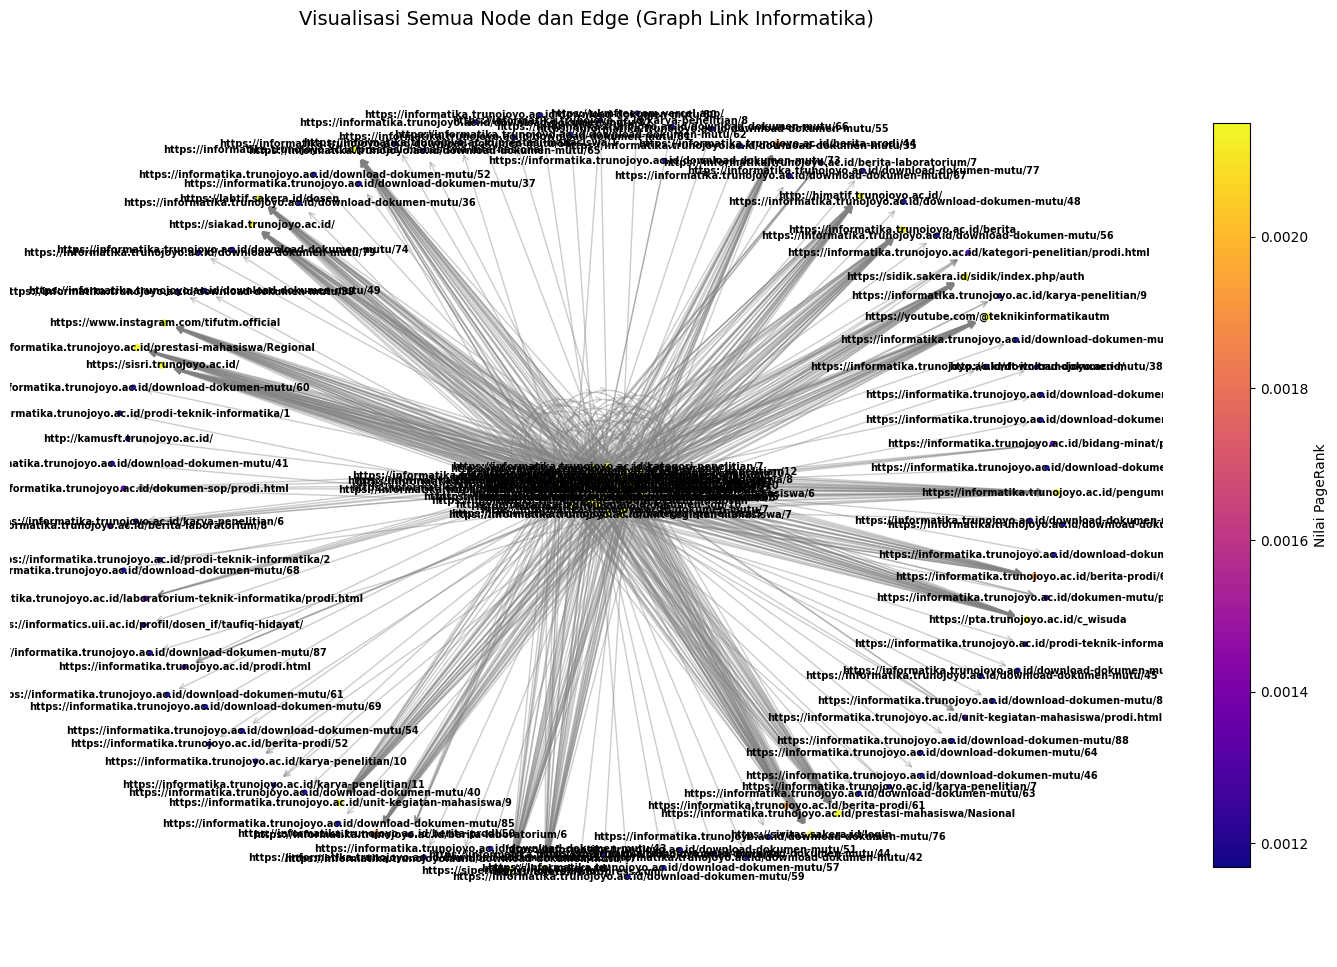

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# === 1. Baca data dan bangun graf ===
file_path = "/content/semua_link (1).csv"

edges = pd.read_csv(file_path, sep=',', comment='#', names=['From', 'To'], skiprows=1)
print(f"Jumlah edge: {len(edges)}")

# Buat graph terarah
G = nx.DiGraph()
for _, row in edges.iterrows():
    G.add_edge(row['From'], row['To'])

print(f"Jumlah node: {len(G.nodes())}")

# === 2. PageRank Manual dengan logging selisih per iterasi (hanya 11 iterasi) ===
alpha = 0.85
max_iter = 100

nodes = list(G.nodes())
N = len(nodes)
pr = dict.fromkeys(nodes, 1/N)  # inisialisasi nilai PageRank
delta_list = []

for i in range(max_iter):
    pr_new = {}
    for node in nodes:
        rank_sum = sum(pr[neighbor]/G.out_degree(neighbor)
                       for neighbor in G.predecessors(node) if G.out_degree(neighbor) > 0)
        pr_new[node] = (1 - alpha)/N + alpha * rank_sum

    # Hitung selisih total L1
    delta = sum(abs(pr_new[n] - pr[n]) for n in nodes)
    delta_list.append(delta)

    # Tampilkan hanya 11 iterasi pertama
    if i < 11:
        print(f"Iterasi {i+1}: selisih total = {delta:.8f}")

    pr = pr_new

# === 3. Simpan hasil PageRank ke DataFrame dan tampilkan Top 5 Node ===
pagerank_df = pd.DataFrame(pr.items(), columns=['Node', 'PageRank']).sort_values(by='PageRank', ascending=False)

print("\n=== 🔝 Top 5 Node dengan PageRank Tertinggi ===")
top_5 = pagerank_df.head(5).reset_index(drop=True)
print(top_5.to_string(index=False))

# === 4. Visualisasi Graph ===
fig, ax = plt.subplots(figsize=(16, 12))

pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)

node_size = [v * 8000 for v in pr.values()]
node_color = list(pr.values())

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color, cmap=plt.cm.plasma, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=10, edge_color='gray', width=1, alpha=0.4, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma)
sm.set_array(node_color)
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Nilai PageRank", fontsize=10)

ax.set_title("Visualisasi Semua Node dan Edge (Graph Link Informatika)", fontsize=14)
ax.axis('off')
plt.show()